In [1]:
# Cell 1 — Project Title 

# 🌸 Day 21 of #100DaysOfCode

# Multi-Class Iris Flower Classification using PyTorch

### Objectives
# - Load the Iris Dataset
# - Visualize the data
# - Preprocess features
# - Build a Neural Network
# - Train the model
# - Evaluate performance
# - Save the trained model

In [2]:
# Cell 2 — Import Libraries

import torch
import torch.nn as nn
import torch.optim as optim

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

plt.style.use("ggplot")

print("✅ Libraries Imported Successfully")

✅ Libraries Imported Successfully


In [3]:
# Cell 3 — Load Dataset

iris = load_iris()

X = iris.data
y = iris.target

df = pd.DataFrame(
    X,
    columns=iris.feature_names
)

df["Species"] = y

print(df.head())

print("\nDataset Shape :", df.shape)

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   Species  
0        0  
1        0  
2        0  
3        0  
4        0  

Dataset Shape : (150, 5)


In [4]:
# Cell 4 — Dataset Information

print(df.info())

print("\nSummary Statistics")

df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   Species            150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB
None

Summary Statistics


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),Species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


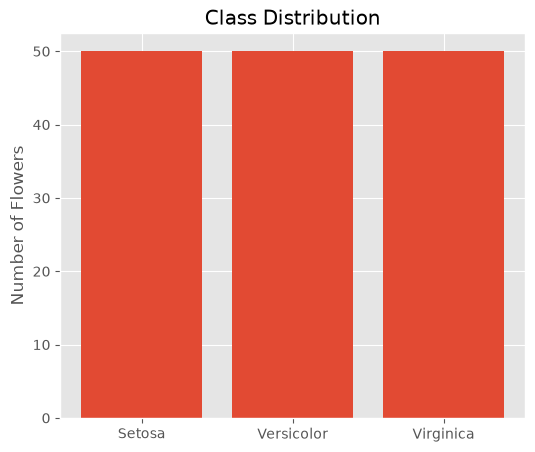

In [5]:
# Cell 5 — Class Distribution

species = ["Setosa","Versicolor","Virginica"]

counts = df["Species"].value_counts()

plt.figure(figsize=(6,5))

plt.bar(
    species,
    counts
)

plt.title("Class Distribution")
plt.ylabel("Number of Flowers")

plt.show()

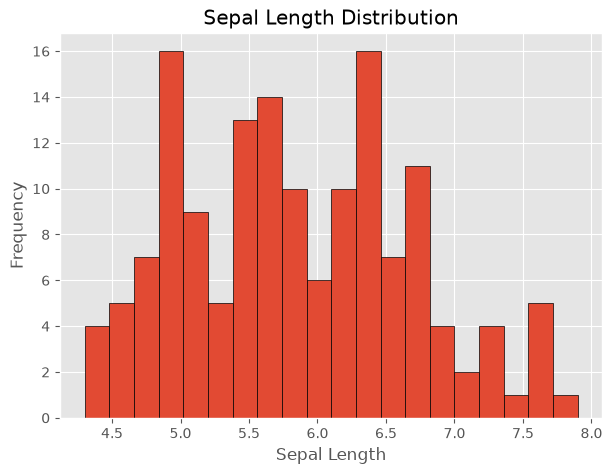

In [6]:
# Cell 6 — Sepal Length Distribution

plt.figure(figsize=(7,5))

plt.hist(
    df["sepal length (cm)"],
    bins=20,
    edgecolor="black"
)

plt.title("Sepal Length Distribution")

plt.xlabel("Sepal Length")

plt.ylabel("Frequency")

plt.show()

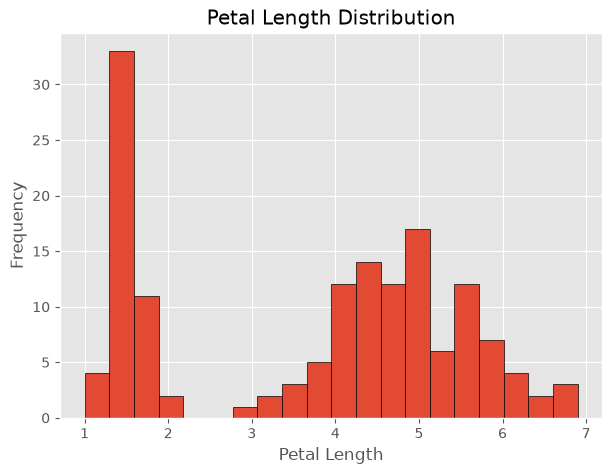

In [7]:
# Cell 7 — Petal Length Distribution

plt.figure(figsize=(7,5))

plt.hist(
    df["petal length (cm)"],
    bins=20,
    edgecolor="black"
)

plt.title("Petal Length Distribution")

plt.xlabel("Petal Length")

plt.ylabel("Frequency")

plt.show()

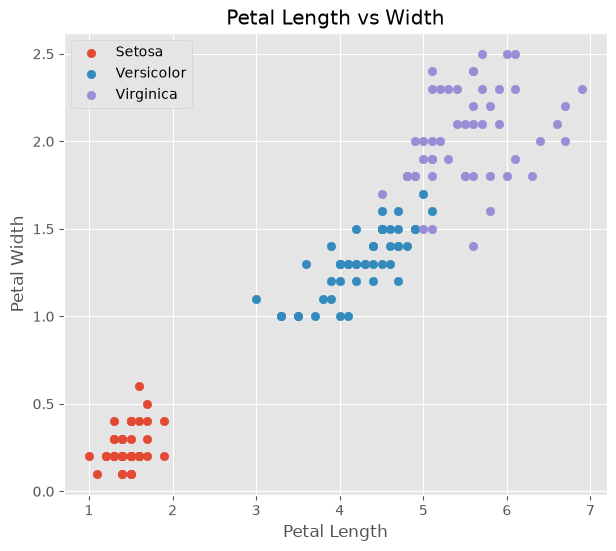

In [8]:
# Cell 8 — Scatter Plot

colors = ["red","green","blue"]

plt.figure(figsize=(7,6))

for i in range(3):

    subset = df[df["Species"]==i]

    plt.scatter(
        subset["petal length (cm)"],
        subset["petal width (cm)"],
        label=species[i]
    )

plt.legend()

plt.xlabel("Petal Length")

plt.ylabel("Petal Width")

plt.title("Petal Length vs Width")

plt.show()

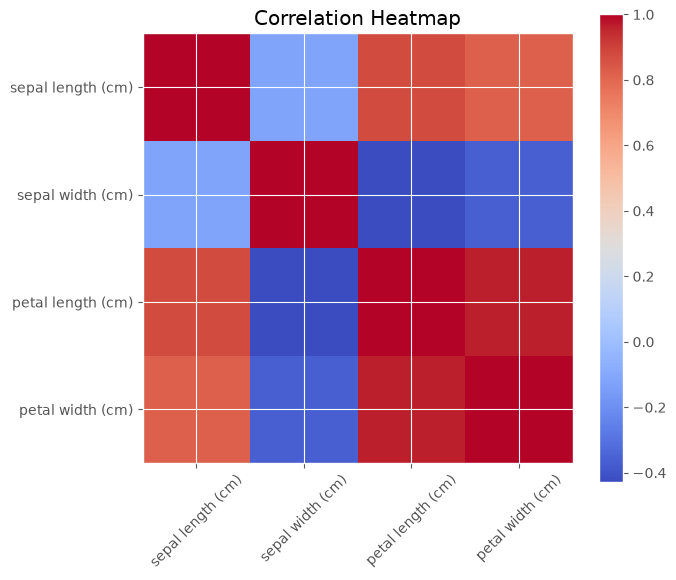

In [9]:
# Cell 9 — Correlation Heatmap

corr = df.iloc[:,:4].corr()

plt.figure(figsize=(7,6))

plt.imshow(
    corr,
    cmap="coolwarm"
)

plt.colorbar()

plt.xticks(
    range(4),
    df.columns[:4],
    rotation=45
)

plt.yticks(
    range(4),
    df.columns[:4]
)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.show()

In [10]:
# Cell 10 — Data Preprocessing

scaler = StandardScaler()

X = scaler.fit_transform(X)

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples :",len(X_train))

print("Testing Samples :",len(X_test))

Training Samples : 120
Testing Samples : 30


In [11]:
# Cell 11 — Convert to Tensor

X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)

y_train = torch.LongTensor(y_train)
y_test = torch.LongTensor(y_test)

print("Tensor Conversion Completed")

Tensor Conversion Completed


In [12]:
# Cell 12 — Build Neural Network

class IrisClassifier(nn.Module):

    def __init__(self):

        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(4,16),

            nn.ReLU(),

            nn.Linear(16,8),

            nn.ReLU(),

            nn.Linear(8,3)

        )

    def forward(self,x):

        return self.network(x)

model = IrisClassifier()

print(model)

IrisClassifier(
  (network): Sequential(
    (0): Linear(in_features=4, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=3, bias=True)
  )
)


In [13]:
# Cell 13 — Loss & Optimizer

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.01
)

print("Model Ready")

Model Ready


In [14]:
# Cell 14 — Train Model

epochs = 100

for epoch in range(epochs):

    outputs = model(X_train)

    loss = criterion(outputs,y_train)

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    if (epoch+1)%10==0:

        print(
            f"Epoch {epoch+1}/{epochs} Loss : {loss.item():.4f}"
        )

Epoch 10/100 Loss : 0.9898
Epoch 20/100 Loss : 0.6343
Epoch 30/100 Loss : 0.3629
Epoch 40/100 Loss : 0.2288
Epoch 50/100 Loss : 0.1353
Epoch 60/100 Loss : 0.0845
Epoch 70/100 Loss : 0.0650
Epoch 80/100 Loss : 0.0560
Epoch 90/100 Loss : 0.0514
Epoch 100/100 Loss : 0.0486


In [15]:
# Cell 15 — Evaluate Model

with torch.no_grad():

    outputs = model(X_test)

    predictions = torch.argmax(outputs,dim=1)

accuracy = accuracy_score(
    y_test,
    predictions
)

print("Accuracy : {:.2f}%".format(accuracy*100))

Accuracy : 100.00%


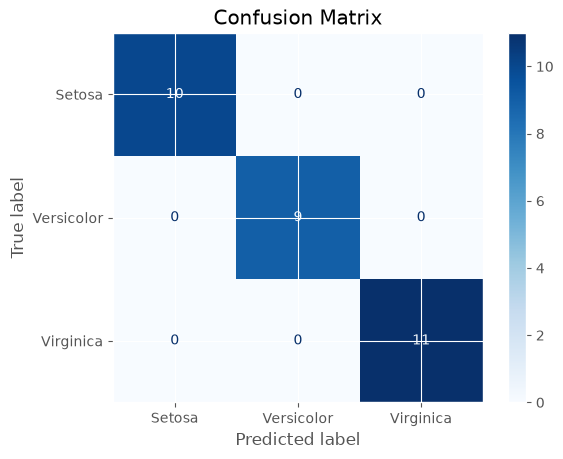

In [16]:
# Cell 16 — Confusion Matrix

cm = confusion_matrix(
    y_test,
    predictions
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=species
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

In [17]:
# Cell 17 — Predict New Flower

sample = X_test[0].unsqueeze(0)

with torch.no_grad():

    prediction = model(sample)

predicted_class = torch.argmax(prediction).item()

print("Predicted Species :",species[predicted_class])

Predicted Species : Versicolor


In [18]:
# Cell 18 — Save Model

torch.save(
    model.state_dict(),
    "iris_classifier.pth"
)

print("Model Saved Successfully!")

Model Saved Successfully!


In [19]:
# Cell 19 — Congratulations 🎉

print("="*60)
print("🎉 CONGRATULATIONS! 🎉")
print("="*60)
print("✅ Day 21 of #100DaysOfCode Completed Successfully!")
print("🌸 Project : Iris Flower Classification using PyTorch")
print("🧠 Learned Multi-Class Classification")
print("📊 Explored and Visualized the Dataset")
print("🤖 Built and Trained a Neural Network")
print("🎯 Evaluated Model Performance")
print("💾 Saved the Trained Model")
print()
print("🚀 Progress: 21/100 Days Completed")
print("🔥 Keep Learning • Keep Building • Keep Growing!")
print("="*60)

🎉 CONGRATULATIONS! 🎉
✅ Day 21 of #100DaysOfCode Completed Successfully!
🌸 Project : Iris Flower Classification using PyTorch
🧠 Learned Multi-Class Classification
📊 Explored and Visualized the Dataset
🤖 Built and Trained a Neural Network
🎯 Evaluated Model Performance
💾 Saved the Trained Model

🚀 Progress: 21/100 Days Completed
🔥 Keep Learning • Keep Building • Keep Growing!
